## GG Diagram Comparison — 1st vs 2nd during Monaco GP Qualifying 2023

The goal of this analysis is to compare the fastest lap of Max Verstappen (1st) 
and Fernando Alonso (2nd) during the 2023 Monaco Grand Prix Qualifying.
We will compare their GG diagrams, helping us understand their driving style 
and whether they reach the car's limits.

Note: this method has limitations as accelerations are computed from GPS 
coordinates, introducing noise into our calculations. This issue impacts 
the precision of our results.

# radius determination fonction 

In [62]:
def euclidean_distance(x1, y1, x2, y2):
    return ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5

def triangle_area(x1, y1, x2, y2, x3, y3):
    
    a = euclidean_distance(x1, y1, x2, y2)
    b = euclidean_distance(x2, y2, x3, y3)
    c = euclidean_distance(x3, y3, x1, y1)

    
    s = (a + b + c) / 2

    
    area = (s * (s - a) * (s - b) * (s - c)) ** 0.5
    return area


def radius(x1, y1, x2, y2, x3, y3):
    area = triangle_area(x1, y1, x2, y2, x3, y3)
    a = euclidean_distance(x1, y1, x2, y2)
    b = euclidean_distance(x2, y2, x3, y3)
    c = euclidean_distance(x3, y3, x1, y1)

    if area == 0:
        return float('inf')  

    radius = (a * b * c) / (4 * area)
    return radius



In [63]:
import fastf1

session = fastf1.get_session(2023, 'Monaco', 'Q')
session.load()


core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '16', '31', '55', '44', '10', '63', '22', '4', '81', '21', '23', '18', '77', '2', '20', '27', '24', '11']


In [64]:
tel_VER = session.laps.pick_driver('VER').pick_fastest().get_telemetry()
print(tel.columns)

tel_ALO = session.laps.pick_driver('ALO').pick_fastest().get_telemetry()

/Users/edouardbougeant/motorsport_env/lib/python3.12/site-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/edouardbougeant/motorsport_env/lib/python3.12/site-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Index(['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time',
       'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z'],
      dtype='object')


# Caluculation of longitudinal / lateral acceleration

In [65]:
import numpy as np

a_lat_list_VER = []
a_long_list_VER = []

speed_ms = tel_VER['Speed'].values / 3.6
time_s   = tel_VER['Time'].dt.total_seconds().values
a_long_VER = np.gradient(speed_ms, time_s)

for i in range(1, len(tel_VER)-1):
   
    x = tel_VER['X'].iloc[i-1:i+2].values
    y = tel_VER['Y'].iloc[i-1:i+2].values
  
    r = radius(x[0], y[0], x[1], y[1], x[2], y[2])

    cross = (x[1]-x[0])*(y[2]-y[1]) - (y[1]-y[0])*(x[2]-x[1])


    sign = 1 if cross > 0 else -1
    a_lat = sign * ((tel['Speed'].iloc[i]/3.6) ** 2) / r if r != 0 else 0
    

    a_lat_list_VER.append(a_lat)
    a_long_list_VER.append(a_long_VER[i])

filtered = [(lat, lon) for lat, lon in zip(a_lat_list_VER, a_long_list_VER) 
            if -40 < lat < 40 and -50 < lon < 15]

a_lat_filtered_VER  = [p[0] for p in filtered]
a_long_filtered_VER = [p[1] for p in filtered]


In [66]:
import numpy as np

a_lat_list_ALO = []
a_long_list_ALO = []

speed_ms = tel_ALO['Speed'].values / 3.6
time_s   = tel_ALO['Time'].dt.total_seconds().values
a_long_ALO = np.gradient(speed_ms, time_s)

for i in range(1, len(tel_ALO)-1):
   
    x = tel_ALO['X'].iloc[i-1:i+2].values
    y = tel_ALO['Y'].iloc[i-1:i+2].values
  
    r = radius(x[0], y[0], x[1], y[1], x[2], y[2])

    cross = (x[1]-x[0])*(y[2]-y[1]) - (y[1]-y[0])*(x[2]-x[1])


    sign = 1 if cross > 0 else -1
    a_lat = sign * ((tel_ALO['Speed'].iloc[i]/3.6) ** 2) / r if r != 0 else 0
    

    a_lat_list_ALO.append(a_lat)
    a_long_list_ALO.append(a_long_ALO[i])

filtered = [(lat, lon) for lat, lon in zip(a_lat_list_ALO, a_long_list_ALO) 
            if -40 < lat < 40 and -50 < lon < 15]

a_lat_filtered_ALO  = [p[0] for p in filtered]
a_long_filtered_ALO = [p[1] for p in filtered]


Text(0.5, 1.0, 'GG Diagram — Alonso Monaco 2023 Qualifying')

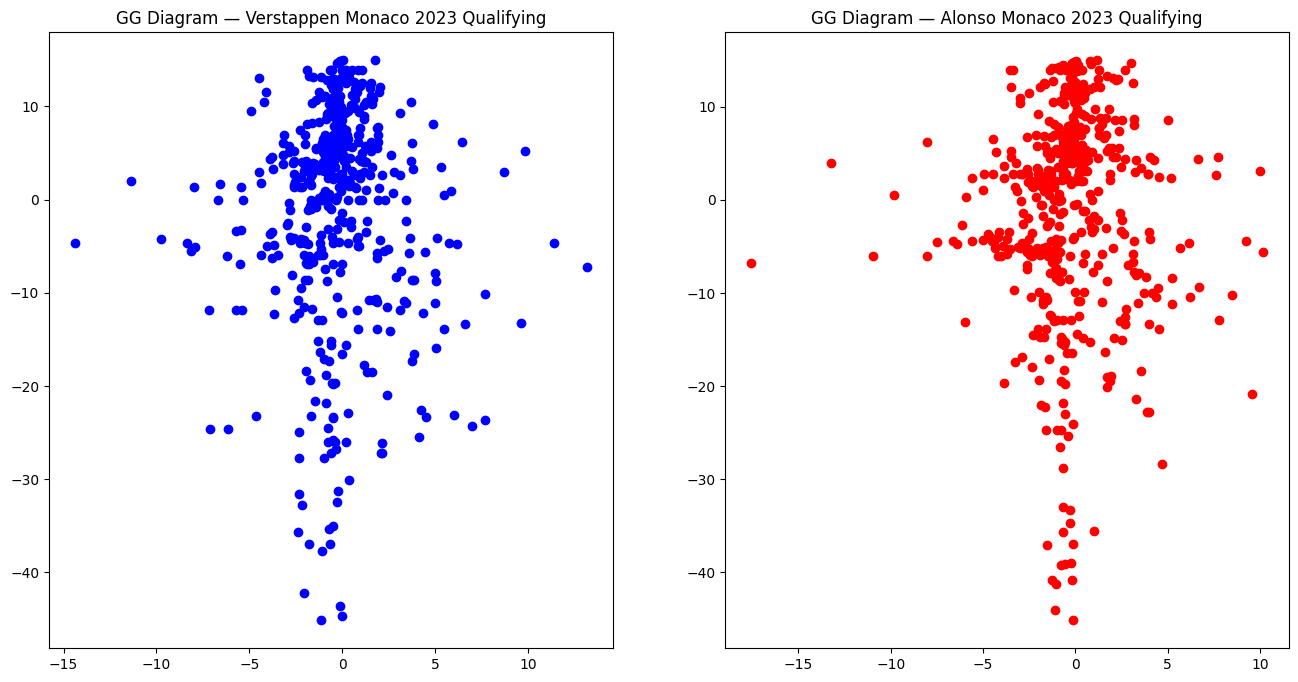

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.scatter(a_lat_filtered_VER, a_long_filtered_VER, color='blue', label='Data points Verstappen')
ax1.set_title('GG Diagram — Verstappen Monaco 2023 Qualifying')

ax2.scatter(a_lat_filtered_ALO, a_long_filtered_ALO, color='red', label='Data points Alonso')
ax2.set_title('GG Diagram — Alonso Monaco 2023 Qualifying')

# Results & Analysis
 
## Observations
 
- Both Alonso and Verstappen push the car to its limits: their GG points consistently reach the boundary of the tyre adherence ellipse.
- The ellipse is common to both drivers, as the tyre compound is significantly more capable of sustaining longitudinal G-forces than lateral ones — hence the elongated elliptical shape.

 
## Driving Style Interpretation
 
- **VER** : Verstappen's GG diagram exhibits a **diamond / ellipse shape**, characteristic of high-speed corner entry combined with late, progressive acceleration once the car is aligned on the straight. Braking and cornering forces tend to overlap, reflecting an aggressive, simultaneous input style.

- **ALO** : Alonso's GG diagram takes on a **cross shape**, indicating a much more decomposed driving approach — braking in a straight line, then turning, then re-accelerating through the corner exit. Each phase is clearly separated, reflecting a deliberate and methodical style.

## Method Limitations
 
- The main limitation of our system stems from **noise in the GPS data**, which propagates through our calculations and gets amplified during the derivation steps (speed → acceleration), resulting in reduced precision in the GG diagrams.
 